In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df_a = pd.read_csv("/content/drive/MyDrive/Eniac-ABTest/eniac_a.csv")
df_b = pd.read_csv("/content/drive/MyDrive/Eniac-ABTest/eniac_b.csv")
df_c = pd.read_csv("/content/drive/MyDrive/Eniac-ABTest/eniac_c.csv")
df_d = pd.read_csv("/content/drive/MyDrive/Eniac-ABTest/eniac_d.csv")

In [ ]:
df_b.head()

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,236,True,Homepage Version B - red SHOP NOW • https:...
1,25,div,mySidebar,304,True,created 2021-10-27 • 14 days 0 hours 34 mi...
2,4,a,Mac,268,True,NaN
3,69,a,iPhone,260,True,NaN
4,105,a,Accessories,1214,True,NaN


In [ ]:
df_a.columns

Index(['Element ID', 'Tag name', 'Name', 'No. clicks', 'Visible?',
       'Snapshot information'],
      dtype='object')

search for SHOP NOW in Version a, b, c, d

In [ ]:
df_a[df_a["Name"].str.contains("SHOP", case=False, na=False)][["Name", "No. clicks"]]


,Name,No. clicks
21,SHOP NOW,512


In [ ]:
df_b[df_b["Name"].str.contains("SHOP", case=False, na=False)][["Name", "No. clicks"]]

,Name,No. clicks
21,SHOP NOW,281


In [ ]:
df_c[df_c["Name"].str.contains("SEE", case=False, na=False)][["Name", "No. clicks"]]


,Name,No. clicks
21,SEE DEALS,527


In [ ]:
df_d[df_d["Name"].str.contains("SEE", case=False, na=False)][["Name", "No. clicks"]]


,Name,No. clicks
21,SEE DEALS,193


create  the summary table of call to action (cta)

In [ ]:
cta_summary = pd.DataFrame({
    "Version": ["A", "B", "C", "D"],
    "Color": ["White", "Red", "White", "Red"],
    "CTA Text": ["SHOP NOW", "SHOP NOW", "SEE DEALS", "SEE DEALS"],
    "Clicks": [512, 281, 527, 193]
})

cta_summary


,Version,Color,CTA Text,Clicks
0,A,White,SHOP NOW,512
1,B,Red,SHOP NOW,281
2,C,White,SEE DEALS,527
3,D,Red,SEE DEALS,193


In [ ]:
# Extraire la chaîne qui contient "visits"
snapshot_b = df_b.loc[df_b["Snapshot information"].str.contains("visits", na=False), "Snapshot information"].values[0]

snapshot_b


'created 2021-10-27   •   14 days 0 hours 34 mins   •   24747 visits, 22407 clicks'

In [ ]:
# Extraire le nombre de visites depuis la chaîne
visits_b = int(snapshot_b.split("visits")[0].split("•")[-1].strip())

visits_b


24747

In [ ]:
def extract_visits(df):
    snapshot = df.loc[df["Snapshot information"].str.contains("visits", na=False), "Snapshot information"].values[0]
    return int(snapshot.split("visits")[0].split("•")[-1].strip())

visits_a = extract_visits(df_a)
visits_b = extract_visits(df_b)
visits_c = extract_visits(df_c)
visits_d = extract_visits(df_d)

visits_a, visits_b, visits_c, visits_d


(25326, 24747, 24876, 25233)

No-clicks=Visits−Clicks

In [ ]:
clicks = {
    "A": 512,
    "B": 281,
    "C": 527,
    "D": 193
}

visits = {
    "A": visits_a,
    "B": visits_b,
    "C": visits_c,
    "D": visits_d
}

no_clicks = {}

for v in clicks:
    no_clicks[v] = visits[v] - clicks[v]

no_clicks


{'A': 24814, 'B': 24466, 'C': 24349, 'D': 25040}

Based on a descriptive analysis of CTA clicks, **Version C (white “SEE DEALS”)** shows the highest performance, while **Version D (red “SEE DEALS”)** performs the worst.

However, **without a statistical significance test**, we cannot conclude whether these observed differences represent **a real effect or are due to random variation**

We have 4 website versions (A, B, C, D).

Each visitor either:

Clicked the CTA button (Click)

Did not click (No-click)

So we test whether Click/No-click depends on the version.

✅ Correct test: Chi-square test of independence (categorical vs categorical, >2 groups)

Step 1 — Define hypotheses

**H0 (Null hypothesis):**

All versions have the same CTR (click behavior is independent of the version).

**H1 (Alternative hypothesis):**

At least one version has a different CTR (click behavior depends on the version).

**Create contingency table**

Rows = user action (Click / No-click( visits − clicks))

Columns = website versions (A, B, C, D)

Each cell = number of observations

👉 This format allows us to test whether click behavior depends on the website version.

In [ ]:
import pandas as pd

# Click data extracted from the CTA buttons
data = {
    "Version_A": [512, 24814],
    "Version_B": [281, 24466],
    "Version_C": [527, 24349],
    "Version_D": [193, 25040]
}

# Create contingency table
contingency_df = pd.DataFrame(
    data,
    index=["Click", "No-click"]
)

contingency_df


,Version_A,Version_B,Version_C,Version_D
Click,512,281,527,193
No-click,24814,24466,24349,25040


In [ ]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_df)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)


Chi-square statistic: 224.01877488058412
Degrees of freedom: 3
p-value: 2.7161216607868712e-48



χ² = 224.02

df = 3

p-value = 2.7 × 10⁻⁴⁸

Significance level α = 0.05

p-value≪0.05

The p-value is extremely smaller than 0.05.

✅ We reject the null hypothesis (H₀).

**Click behavior** is NOT due to chance.

The **CTR** clearly depends on the version of the button.

The differences in clicks between A, B, C, and D are **real**

They are** not random fluctuations**

Now that we know differences exist, the next steps are:

**Post-hoc pairwise tests**
→ to identify which versions differ from each other

**Bonferroni correction**
→ to control Type I error

**Combine with drop-off rate & homepage-return rate**
→ to decide if there is a true winn

Although **the chi-square test **indicates that **click behavior depends on the website version**, it does not identify a** single winning variant**.

Post-hoc considerations and additional engagement metrics show that while **Version C has the highest CTR, the differences between all variants are not consistently significant**. Therefore, no single clear winner can be identified.

**Click-through rate (CTR)**
The percentage of homepage visitors who click on the CTA button. It measures how effective the button is at encouraging initial user interaction.

**Drop-off rate**
The percentage of users who start a conversion process after clicking the button but do not complete it. It indicates how well users stay engaged after the click.

**Homepage-return rate**
The percentage of users who return to the homepage after clicking the button. It indicates whether users find the content they expect on the linked page.

**1️⃣ Drop-Off Rate — Interpretation**

📌 **Reminder**

Th**e drop-off rate** measures the proportion of users who click on the CTA but then abandon the process without continuing.

👉 A higher drop-off rate indicates worse performance.

Reading the chart

Version C → highest drop-off rate (~71%) ❌

Version D → very high drop-off rate (~69%) ❌

**Version A** → lower drop-off rate (~62%) ✅

Version B → missing data (not interpretable)

**Interpretation**
👉 The SEE DEALS versions (especially Version C) generate many clicks,
but a large share of users leave shortly after clicking.

➡️ This suggests a mismatch between the promise of the CTA and the content shown after the click.

**2️⃣ Homepage-Return Rate — Interpretation**

📌** Reminder**

The** homepage-return rate** measures the proportion of users who:
click on the CTA,
and then return to the homepage.

👉 A higher homepage-return rate indicates confusion or frustration.

Reading the chart

Version A → highest return rate (~5.3%) ❌

Version C → high return rate (~4.7%) ❌

**Version D** → lower return rate (~2.6%) ✅

Version B → missing data

**Interpretation**

👉 A significant number of users return to the homepage, especially for:
Version A
Version C

➡️ This suggests that users may not be immediately finding the information or content they expect after clicking the CTA.

**⃣ Putting the results into perspective with CTR**

CTR recap (click performance):

Version C → highest CTR

Version A → second highest

Versions B and D → lower CTRs

However…
**Version C**:

✔️ generates many clicks

❌ shows a high drop-off rate

❌ shows a high homepage-return rate

👉 A high CTR alone does not necessarily indicate a good user experience or effective conversion.

# **Final decision **

❓ With the results of the chi-square test and the additional engagement metrics, which version is the winner?

👉 **There is no single clear winner**.

Why?

The chi-square test shows that differences in CTR across versions are statistically significant.

However:
Post-click metrics (drop-off rate and homepage-return rate) reveal engagement issues.

No version combines high CTR with strong post-click retention.

Important nuance about Version D and missing data

Version D shows:
a lower CTR,
but relatively better post-click behavior compared to Version C.

Version B cannot be properly evaluated due to missing post-click data.

👉 Because of the missing data for Version B, we cannot confidently conclude whether Version D could outperform other versions in a fully comparable analysis.


Although the chi-square test confirms that CTR differs across versions, post-click engagement metrics do not support selecting a single winning variant.
While Version C achieves the highest CTR, its high drop-off and homepage-return rates indicate weak engagement.
Version D shows more stable post-click behavior, but missing data for Version B prevents a complete comparison.

** Therefore, no single clear winner can be identified.**

company will stay with version A

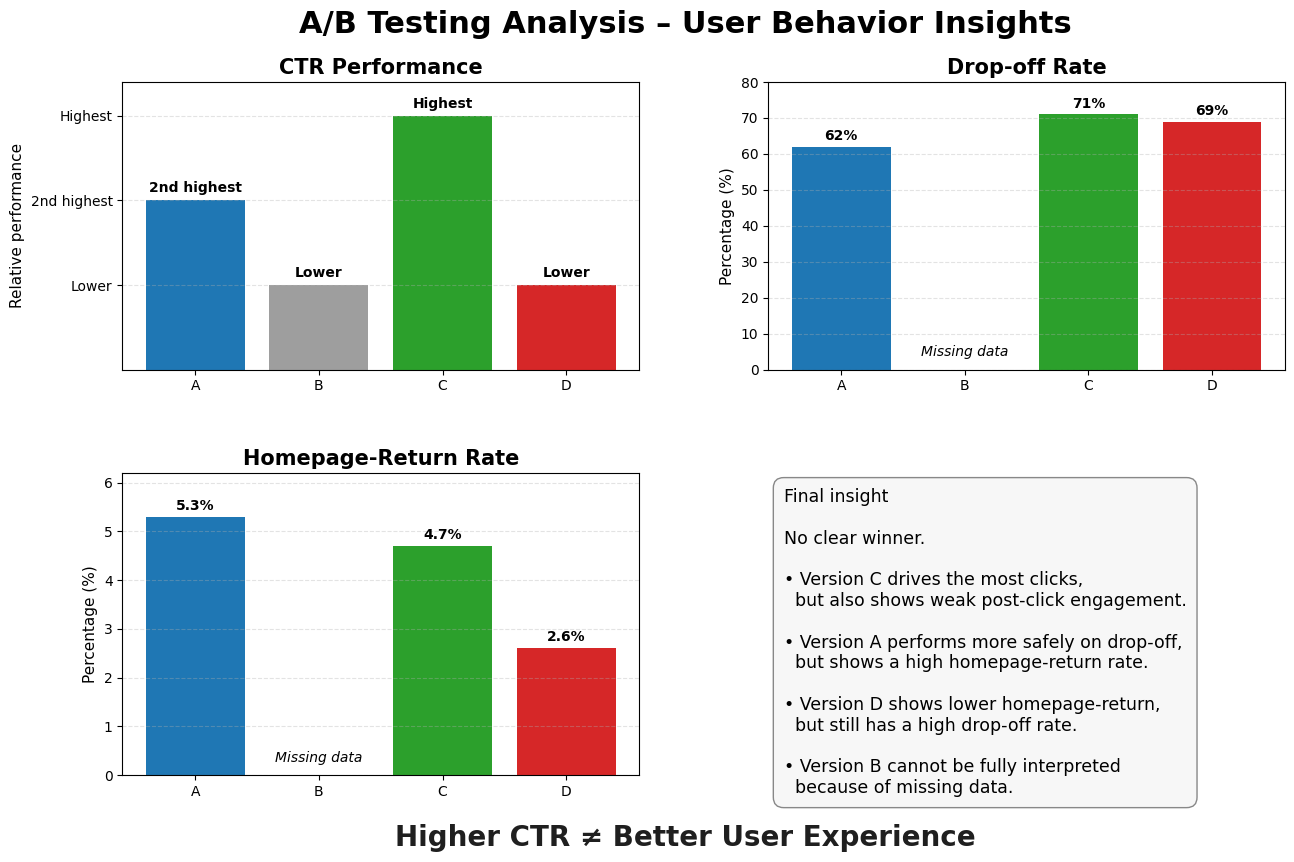

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATA FROM YOUR ANALYSIS
# =========================

# CTR ranking from your analysis
# C = highest, A = second highest, B and D = lower
variants = ["A", "B", "C", "D"]
ctr_scores = [2, 1, 3, 1]  # relative performance only
ctr_labels = ["2nd highest", "Lower", "Highest", "Lower"]

# Drop-off rate (%)
dropoff_values = [62, np.nan, 71, 69]

# Homepage-return rate (%)
return_values = [5.3, np.nan, 4.7, 2.6]

# Colors for consistency across charts
colors = ["#1f77b4", "#9e9e9e", "#2ca02c", "#d62728"]

# =========================
# FIGURE LAYOUT
# =========================
fig = plt.figure(figsize=(15, 9), facecolor="white")
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.05], hspace=0.35, wspace=0.25)

ax1 = fig.add_subplot(gs[0, 0])  # CTR
ax2 = fig.add_subplot(gs[0, 1])  # Drop-off
ax3 = fig.add_subplot(gs[1, 0])  # Return rate
ax4 = fig.add_subplot(gs[1, 1])  # Final insight

fig.suptitle("A/B Testing Analysis – User Behavior Insights",
             fontsize=22, fontweight="bold", y=0.96)

# =========================
# 1) CTR PERFORMANCE
# =========================
bars1 = ax1.bar(variants, ctr_scores, color=colors)

ax1.set_title("CTR Performance", fontsize=15, fontweight="bold")
ax1.set_ylabel("Relative performance", fontsize=11)
ax1.set_ylim(0, 3.4)
ax1.set_yticks([1, 2, 3])
ax1.set_yticklabels(["Lower", "2nd highest", "Highest"])
ax1.grid(axis="y", linestyle="--", alpha=0.35)

for bar, label in zip(bars1, ctr_labels):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.06,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# =========================
# 2) DROP-OFF RATE
# =========================
for i, val in enumerate(dropoff_values):
    if np.isnan(val):
        ax2.bar(variants[i], 0, color=colors[i], alpha=0.25)
        ax2.text(i, 3, "Missing data", ha="center", va="bottom",
                 fontsize=10, style="italic")
    else:
        ax2.bar(variants[i], val, color=colors[i])
        ax2.text(i, val + 1, f"{val}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

ax2.set_title("Drop-off Rate", fontsize=15, fontweight="bold")
ax2.set_ylabel("Percentage (%)", fontsize=11)
ax2.set_ylim(0, 80)
ax2.grid(axis="y", linestyle="--", alpha=0.35)

# =========================
# 3) HOMEPAGE-RETURN RATE
# =========================
for i, val in enumerate(return_values):
    if np.isnan(val):
        ax3.bar(variants[i], 0, color=colors[i], alpha=0.25)
        ax3.text(i, 0.2, "Missing data", ha="center", va="bottom",
                 fontsize=10, style="italic")
    else:
        ax3.bar(variants[i], val, color=colors[i])
        ax3.text(i, val + 0.08, f"{val}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

ax3.set_title("Homepage-Return Rate", fontsize=15, fontweight="bold")
ax3.set_ylabel("Percentage (%)", fontsize=11)
ax3.set_ylim(0, 6.2)
ax3.grid(axis="y", linestyle="--", alpha=0.35)

# =========================
# 4) FINAL INSIGHT PANEL
# =========================
ax4.axis("off")

summary_text = (
    "Final insight\n\n"
    "No clear winner.\n\n"
    "• Version C drives the most clicks,\n"
    "  but also shows weak post-click engagement.\n\n"
    "• Version A performs more safely on drop-off,\n"
    "  but shows a high homepage-return rate.\n\n"
    "• Version D shows lower homepage-return,\n"
    "  but still has a high drop-off rate.\n\n"
    "• Version B cannot be fully interpreted\n"
    "  because of missing data."
)

ax4.text(
    0.03, 0.95, summary_text,
    transform=ax4.transAxes,
    fontsize=12.5,
    va="top",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f7f7f7", edgecolor="#888888")
)

# =========================
# BIG MESSAGE AT THE BOTTOM
# =========================
fig.text(
    0.5, 0.04,
    "Higher CTR ≠ Better User Experience",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#1f1f1f"
)

plt.show()